# World Bank World Development Indicators: Data Exploration

Each exploration notebook for a data source should work through the key steps:
1. Loading the data
2. Determining the observation units and the variables of interest
3. Locating and handling missing data
4. Transforming/adding new variables
5. Creating and saving clean subsets
6. Identifying the key dimensions in the dataset (temporal, spatial, categorical)
7. Listing the key questions relating to the overarching research questions
8. Carrying out descriptive analysis of each of the key variables and relevant combinations

## 1. Loading the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
import warnings
warnings.simplefilter('ignore')

In [4]:
# Load World Bank WDI data
# na_values=['..'] converts World Bank missing data markers to NaN
wb = pd.read_csv('../data/raw/worldbank_wdi_raw.csv', na_values=['..'])

print(f'Shape: {wb.shape}')
print(f'\nColumns: {list(wb.columns)}')
wb.head()

Shape: (1069, 19)

Columns: ['Country Name', 'Country Code', 'Series Name', 'Series Code', '2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']


,Country Name,Country Code,Series Name,Series Code,2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,1744.060623,1988.429304,2133.241271,2224.490748,2284.075848,2213.181441,2335.795862,2432.276701,2583.485332,2561.981761,2144.166570,2122.995815,2201.722907,NaN,NaN
1,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,61.250000,61.735000,62.188000,62.260000,62.270000,62.646000,62.406000,62.443000,62.941000,61.454000,60.417000,65.617000,66.035000,NaN,NaN
3,Afghanistan,AFG,"Current health expenditure per capita, PPP (cu...",SH.XPD.CHEX.PP.CD,146.844396,157.761765,184.226284,213.152665,231.533668,261.566867,294.796437,345.587947,383.164896,401.163333,461.176859,490.161282,329.823208,NaN,NaN
4,Albania,ALB,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,10273.419978,10608.844817,10882.026129,11787.854964,12386.592267,13055.841747,14110.683242,15055.280800,16442.125939,16287.609766,18212.870247,22138.418286,24822.354309,26701.674956,NaN


In [5]:
# Load WHO data
hale = pd.read_csv('../data/raw/who_hale_at_birth.csv')
le   = pd.read_csv('../data/raw/who_le_at_birth.csv')

print(f'HALE shape: {hale.shape}')
print(f'Life expectancy shape: {le.shape}')

HALE shape: (24420, 34)
Life expectancy shape: (24420, 34)


## 2. Observation Units and Variables of Interest

The World Bank dataset is in long format: each row is one country, one indicator, one year.

**Observation unit:** Country-year-indicator combination

**Variables of interest:**
- `GDP per capita, PPP (current international $)` - national wealth adjusted for purchasing power
- `Gini index` - income inequality within each country
- `Life expectancy at birth, total (years)` - cross-check against WHO data
- `Current health expenditure per capita, PPP (current international $)` - healthcare spending

In [6]:
# Check which indicators are in the dataset
print('Indicators in dataset:')
print(wb['Series Name'].unique())

Indicators in dataset:
<ArrowStringArray>
[                       'GDP per capita, PPP (current international $)',
                                                           'Gini index',
                              'Life expectancy at birth, total (years)',
 'Current health expenditure per capita, PPP (current international $)',
                                                                    nan]
Length: 5, dtype: str


In [7]:
# Check year columns available
year_cols = [c for c in wb.columns if 'YR' in str(c)]
print(f'Year columns: {year_cols}')
print(f'Countries: {wb["Country Name"].nunique()}')

Year columns: ['2011 [YR2011]', '2012 [YR2012]', '2013 [YR2013]', '2014 [YR2014]', '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]']
Countries: 268


## 3. Reshaping and Handling Missing Data

The World Bank data comes in wide format (one column per year). We reshape it to long format for easier analysis.

In [8]:
# Melt from wide to long format
year_cols = [c for c in wb.columns if 'YR' in str(c)]

wb_long = wb.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='year_raw',
    value_name='value'
)

# Extract clean year integer
wb_long['year'] = wb_long['year_raw'].str.extract(r'(\d{4})').astype(int)
wb_long = wb_long.drop(columns='year_raw')

print(f'Shape after melt: {wb_long.shape}')
wb_long.head()

Shape after melt: (16035, 6)


,Country Name,Country Code,Series Name,Series Code,value,year
0,Afghanistan,AFG,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,1744.060623,2011
1,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,2011
2,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,61.250000,2011
3,Afghanistan,AFG,"Current health expenditure per capita, PPP (cu...",SH.XPD.CHEX.PP.CD,146.844396,2011
4,Albania,ALB,"GDP per capita, PPP (current international $)",NY.GDP.PCAP.PP.CD,10273.419978,2011


In [9]:
# Check missing data per indicator
missing = wb_long.groupby('Series Name')['value'].apply(lambda x: x.isna().sum())
total   = wb_long.groupby('Series Name')['value'].count()
pct_missing = (missing / (missing + total) * 100).round(1)

print('Missing data per indicator (%):')
print(pct_missing.to_string())

Missing data per indicator (%):
Series Name
Current health expenditure per capita, PPP (current international $)    21.5
GDP per capita, PPP (current international $)                           13.6
Gini index                                                              74.2
Life expectancy at birth, total (years)                                 13.7


In [10]:
# Gini index has significant missing data - check which countries have it
gini = wb_long[wb_long['Series Name'] == 'Gini index'].dropna(subset=['value'])
print(f'Countries with Gini data: {gini["Country Name"].nunique()}')
print(f'Years with Gini data: {sorted(gini["year"].unique())}')

Countries with Gini data: 163
Years with Gini data: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


## 4. Transforming and Adding New Variables

In [11]:
# Pivot to wide format with one column per indicator - easier to work with
wb_wide = wb_long.pivot_table(
    index=['Country Name', 'Country Code', 'year'],
    columns='Series Name',
    values='value'
).reset_index()

# Renaming columns
wb_wide.columns.name = None
wb_wide = wb_wide.rename(columns={
    'GDP per capita, PPP (current international $)':'gdp_per_capita_ppp',
    'Gini index':'gini',
    'Life expectancy at birth, total (years)':'life_expectancy',
    'Current health expenditure per capita, PPP (current international $)':'health_expenditure_ppp',
    'Country Name':'country',
    'Country Code':'country_code',
})

print(f'Shape: {wb_wide.shape}')
wb_wide.head()

Shape: (3681, 7)


,country,country_code,year,health_expenditure_ppp,gdp_per_capita_ppp,gini,life_expectancy
0,Afghanistan,AFG,2011,146.844396,1744.060623,NaN,61.250
1,Afghanistan,AFG,2012,157.761765,1988.429304,NaN,61.735
2,Afghanistan,AFG,2013,184.226284,2133.241271,NaN,62.188
3,Afghanistan,AFG,2014,213.152665,2224.490748,NaN,62.260
4,Afghanistan,AFG,2015,231.533668,2284.075848,NaN,62.270


In [12]:
# Add log GDP per capita - useful for scatter plots to reduce skew
wb_wide['log_gdp_per_capita'] = np.log(wb_wide['gdp_per_capita_ppp'])

# Add GDP group (low, middle, high income) based on World Bank thresholds
def gdp_group(gdp):
    if pd.isna(gdp):    return np.nan
    elif gdp < 4500:    return 'Low income'
    elif gdp < 14000:   return 'Lower-middle income'
    elif gdp < 45000:   return 'Upper-middle income'
    else:               return 'High income'

wb_wide['income_group'] = wb_wide['gdp_per_capita_ppp'].apply(gdp_group)
print(wb_wide['income_group'].value_counts())

income_group
Upper-middle income    1207
Lower-middle income     960
Low income              728
High income             552
Name: count, dtype: int64


## 5. Creating and Saving Clean Subsets

In [13]:
# Save full clean dataset
wb_wide.to_csv('../data/clean/world_bank_clean.csv', index=False)
print(f'Saved world_bank_clean.csv - {wb_wide.shape[0]} rows')

# Save most recent year only for cross-sectional analysis
wb_latest = wb_wide[wb_wide['year'] == wb_wide['year'].max()].dropna(subset=['gdp_per_capita_ppp'])
wb_latest.to_csv('../data/clean/world_bank_latest.csv', index=False)
print(f'Saved world_bank_latest.csv - {wb_latest.shape[0]} rows')

Saved world_bank_clean.csv - 3681 rows
Saved world_bank_latest.csv - 236 rows


## 6. Key Dimensions in the Dataset

- **Temporal:** 2011 to 2024, annual
- **Spatial:** 217 countries globally
- **Categorical:** Income group (low, lower-middle, upper-middle, high)
- **Key limitation:** Gini index has significant missing data, especially for recent years

In [14]:
# Coverage summary
print('Countries per year with GDP data:')
print(wb_wide.dropna(subset=['gdp_per_capita_ppp']).groupby('year')['country'].count().to_string())

Countries per year with GDP data:
year
2011    249
2012    247
2013    248
2014    247
2015    247
2016    246
2017    247
2018    247
2019    247
2020    247
2021    247
2022    247
2023    245
2024    236


## 7. Key Questions Relating to the Research Questions

1. Does GDP per capita predict where sweet spot cities (high quality, low cost) tend to be located?
2. Do countries with high income inequality (high Gini) produce cities that score poorly on quality of life despite being affordable?
3. Is there a middle-income sweet spot - countries wealthy enough to have decent infrastructure but not so expensive that costs are prohibitive?
4. Does healthcare expenditure per capita correlate with Numbeo's healthcare index at the country level?
5. How does World Bank life expectancy compare to WHO life expectancy for the same countries?

## 8. Descriptive Analysis

In [15]:
# GDP per capita distribution in latest year
latest = wb_wide[wb_wide['year'] == wb_wide['year'].max()]

print('GDP per capita PPP summary (latest year):')
print(latest['gdp_per_capita_ppp'].describe().round(0))

GDP per capita PPP summary (latest year):
count       236.0
mean      30330.0
std       29588.0
min        1195.0
25%        7660.0
50%       20832.0
75%       47587.0
max      155941.0
Name: gdp_per_capita_ppp, dtype: float64


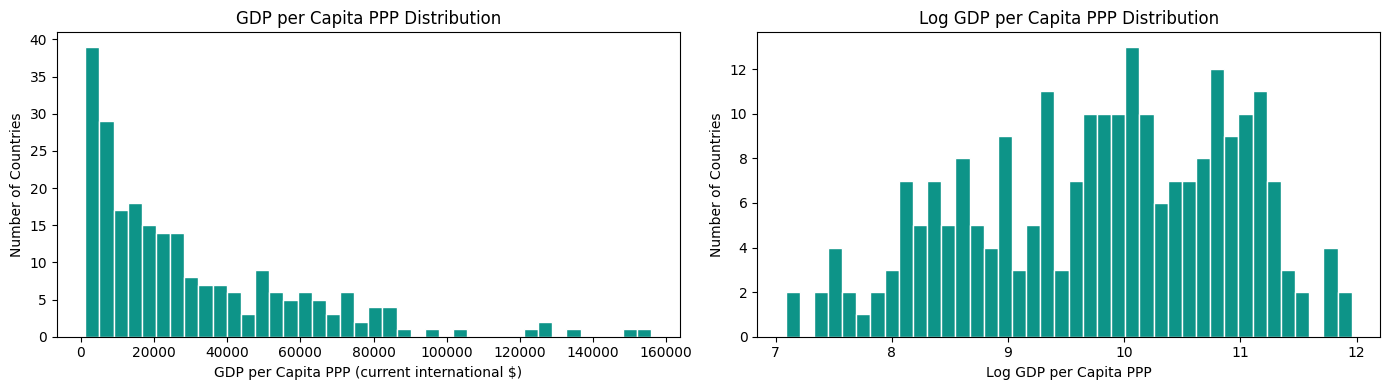

In [16]:
# GDP per capita distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(latest['gdp_per_capita_ppp'].dropna(), bins=40, color='#0D9488', edgecolor='white')
axes[0].set_title('GDP per Capita PPP Distribution')
axes[0].set_xlabel('GDP per Capita PPP (current international $)')
axes[0].set_ylabel('Number of Countries')

axes[1].hist(latest['log_gdp_per_capita'].dropna(), bins=40, color='#0D9488', edgecolor='white')
axes[1].set_title('Log GDP per Capita PPP Distribution')
axes[1].set_xlabel('Log GDP per Capita PPP')
axes[1].set_ylabel('Number of Countries')

plt.tight_layout()
plt.show()

In [17]:
# Gini index summary
print('Gini index summary (most recent available per country):')
gini_latest = wb_wide.dropna(subset=['gini']).sort_values('year', ascending=False).drop_duplicates('country')
print(gini_latest['gini'].describe().round(2))

print(f'\nMost unequal countries:')
print(gini_latest.nlargest(10, 'gini')[['country', 'gini', 'year']].to_string(index=False))

print(f'\nMost equal countries:')
print(gini_latest.nsmallest(10, 'gini')[['country', 'gini', 'year']].to_string(index=False))

Gini index summary (most recent available per country):
count    163.00
mean      36.34
std        7.28
min       23.80
25%       31.10
50%       35.30
75%       40.10
max       63.00
Name: gini, dtype: float64

Most unequal countries:
     country  gini  year
South Africa  63.0  2014
     Namibia  59.1  2015
    Botswana  54.9  2015
    Eswatini  54.6  2016
    Colombia  53.9  2023
      Brazil  51.6  2023
      Zambia  51.5  2022
      Angola  51.3  2018
    Zimbabwe  50.3  2019
      Panama  49.7  2024

Most equal countries:
             country  gini  year
     Slovak Republic  23.8  2023
             Belarus  24.4  2020
            Slovenia  24.7  2023
               India  25.5  2022
             Ukraine  25.6  2020
             Czechia  25.7  2023
         Netherlands  25.7  2021
United Arab Emirates  26.4  2018
              Norway  26.5  2023
Syrian Arab Republic  26.6  2022


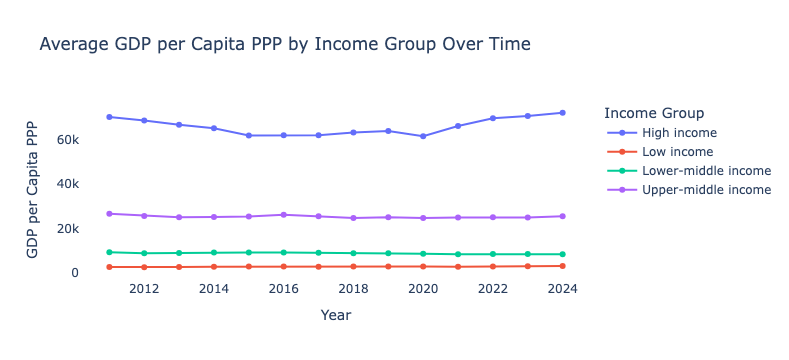

In [26]:
# Average GDP per capita by income group over time
gdp_trend = wb_wide.groupby(['year', 'income_group'])['gdp_per_capita_ppp'].mean().reset_index()

fig = px.line(
    gdp_trend.dropna(subset=['income_group']),
    x='year',
    y='gdp_per_capita_ppp',
    color='income_group',
    title='Average GDP per Capita PPP by Income Group Over Time',
    markers=True,
    labels={'gdp_per_capita_ppp': 'GDP per Capita PPP', 'year': 'Year', 'income_group': 'Income Group'}
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

In [27]:
print(latest[['country', 'year', 'life_expectancy']].head(20))

                         country  year  life_expectancy
26   Africa Eastern and Southern  2024              NaN
40    Africa Western and Central  2024              NaN
54                       Albania  2024              NaN
68                       Algeria  2024              NaN
95                       Andorra  2024              NaN
109                       Angola  2024              NaN
123          Antigua and Barbuda  2024              NaN
137                   Arab World  2024              NaN
151                    Argentina  2024              NaN
165                      Armenia  2024              NaN
179                        Aruba  2024              NaN
193                    Australia  2024              NaN
207                      Austria  2024              NaN
221                   Azerbaijan  2024              NaN
235                 Bahamas, The  2024              NaN
249                      Bahrain  2024              NaN
263                   Bangladesh  2024          

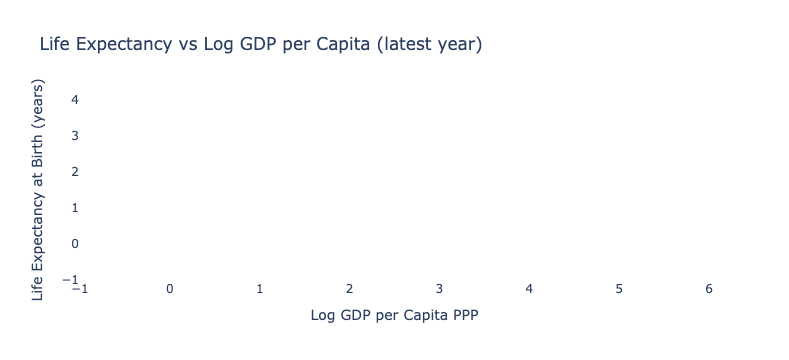

In [24]:
# Life expectancy vs GDP per capita - does wealth predict health?
latest['life_expectancy'] = pd.to_numeric(
    latest['life_expectancy'],
    errors='coerce'
)

latest_clean = latest.dropna(
    subset=['log_gdp_per_capita', 'life_expectancy']
)

fig = px.scatter(
    latest_clean,
    x='log_gdp_per_capita',
    y='life_expectancy',
    hover_name='country',
    color='income_group',
    title='Life Expectancy vs Log GDP per Capita (latest year)',
    labels={
        'log_gdp_per_capita': 'Log GDP per Capita PPP',
        'life_expectancy': 'Life Expectancy at Birth (years)',
        'income_group': 'Income Group'
    }
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

In [25]:
latest_clean = latest.dropna(
    subset=['log_gdp_per_capita', 'life_expectancy']
)

print("latest_clean shape:", latest_clean.shape)

latest_clean shape: (0, 9)


Countries with both Gini and life expectancy: 163
Correlation between Gini and life expectancy: r = -0.330, p = 0.000


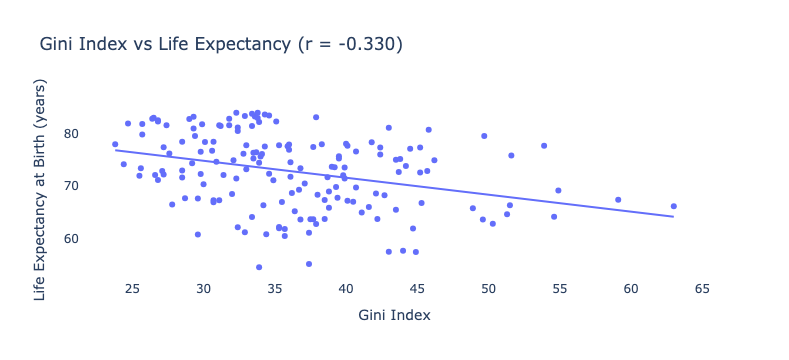

In [24]:
# Use most recent available Gini per country instead of latest year only
gini_latest = wb_wide.dropna(subset=['gini']).sort_values('year', ascending=False).drop_duplicates('country')
le_latest   = wb_wide.dropna(subset=['life_expectancy']).sort_values('year', ascending=False).drop_duplicates('country')

gini_le = pd.merge(
    gini_latest[['country', 'gini']],
    le_latest[['country', 'life_expectancy']],
    on='country'
)

print(f'Countries with both Gini and life expectancy: {len(gini_le)}')

r, p = stats.pearsonr(gini_le['gini'], gini_le['life_expectancy'])
print(f'Correlation between Gini and life expectancy: r = {r:.3f}, p = {p:.3f}')

fig = px.scatter(
    gini_le,
    x='gini',
    y='life_expectancy',
    hover_name='country',
    trendline='ols',
    title=f'Gini Index vs Life Expectancy (r = {r:.3f})',
    labels={'gini': 'Gini Index', 'life_expectancy': 'Life Expectancy at Birth (years)'}
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

In [20]:
# Compare WHO life expectancy vs World Bank life expectancy
# Clean WHO data first
le_clean = le[le['Dim1'] == 'Both sexes'][['SpatialDimValueCode', 'Location', 'Period', 'FactValueNumeric']].rename(columns={
    'SpatialDimValueCode': 'country_code',
    'Location': 'country_who',
    'Period': 'year',
    'FactValueNumeric': 'le_who'
})

# Merge with World Bank on country code and year
wb_who = pd.merge(
    wb_wide[['country_code', 'country', 'year', 'life_expectancy']].rename(columns={'life_expectancy': 'le_wb'}),
    le_clean,
    on=['country_code', 'year'],
    how='inner'
).dropna()

r, p = stats.pearsonr(wb_who['le_wb'], wb_who['le_who'])
print(f'Correlation between WB and WHO life expectancy: r = {r:.3f}, p = {p:.4f}')

# Countries where they diverge most
wb_who['difference'] = (wb_who['le_wb'] - wb_who['le_who']).abs()
print('\nCountries with biggest divergence between WB and WHO:')
print(wb_who.nlargest(10, 'difference')[['country', 'year', 'le_wb', 'le_who', 'difference']].to_string(index=False))

Correlation between WB and WHO life expectancy: r = 0.190, p = 0.0000

Countries with biggest divergence between WB and WHO:
 country  year  le_wb  le_who  difference
   Qatar  2011 79.994   17.91      62.084
   Qatar  2012 80.499   18.52      61.979
Maldives  2019 79.707   17.90      61.807
   Qatar  2013 80.974   19.23      61.744
 Bahrain  2012 79.622   17.97      61.652
 Bahrain  2013 79.998   18.37      61.628
   Qatar  2021 81.083   19.47      61.613
 Bahrain  2016 80.407   18.80      61.607
 Bahrain  2017 80.407   18.85      61.557
 Bahrain  2011 79.141   17.61      61.531


In [21]:
# Health expenditure per capita summary
print('Health expenditure per capita PPP summary (latest year):')
print(latest['health_expenditure_ppp'].describe().round(0))

print('\nTop 10 highest health spenders:')
print(latest.nlargest(10, 'health_expenditure_ppp')[['country', 'health_expenditure_ppp']].to_string(index=False))

print('\nBottom 10 lowest health spenders:')
print(latest.nsmallest(10, 'health_expenditure_ppp')[['country', 'health_expenditure_ppp']].to_string(index=False))

Health expenditure per capita PPP summary (latest year):
count      24.0
mean     6150.0
std      1932.0
min      1758.0
25%      4865.0
50%      6654.0
75%      7677.0
max      8826.0
Name: health_expenditure_ppp, dtype: float64

Top 10 highest health spenders:
    country  health_expenditure_ppp
    Germany             8825.614808
 Luxembourg             8807.585582
    Ireland             8772.473100
    Austria             8250.106667
Netherlands             8194.568175
     Sweden             7770.396736
     Canada             7645.926993
    Denmark             7261.553606
  Euro area             7117.011961
    Iceland             6926.884144

Bottom 10 lowest health spenders:
    country  health_expenditure_ppp
   Colombia             1757.869203
      Chile             3611.904162
    Estonia             3740.861064
     Poland             3938.954723
  Lithuania             4127.402386
    Czechia             4674.026762
   Portugal             4928.031320
      Italy       

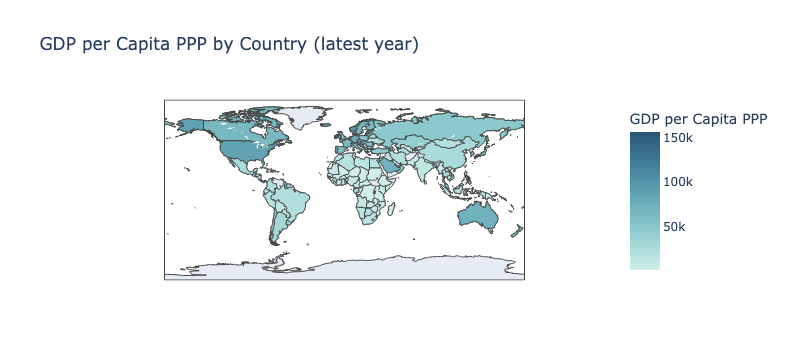

In [22]:
# Choropleth of GDP per capita
fig = px.choropleth(
    latest.dropna(subset=['gdp_per_capita_ppp']),
    locations='country_code',
    color='gdp_per_capita_ppp',
    hover_name='country',
    color_continuous_scale='Teal',
    title='GDP per Capita PPP by Country (latest year)',
    labels={'gdp_per_capita_ppp': 'GDP per Capita PPP'}
)
fig.show()